# Helpdesk training — improved (henryk / U-ED-LSTM)

Sibling of `src/notebooks/training_variational_dropout/Helpdesk/full_enc_dec_lstm_gn.ipynb`. Active modifications:

- **§1 (revised)** — train-only oversampling of `Insert ticket`-start cases (`DUPLICATE_FACTOR = 40`).
- **Test #1** — `StandardCEActivityLoss` subclass: activity head uses plain CE instead of `loss_attenuation_cross_entropy`. Resource head + time heads keep their attenuated form.

Reads pkls from sibling `Loader/pkl/`. Saves checkpoint to sibling `Training/pkl/`.

## Imports

In [1]:
import importlib
import os
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
import pickle
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm


## Data — load augmented train/val from `encoded_data/improved/`

In [2]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
PROJECT_ROOT = Path('../../../../../../../..').resolve()

file_path_train = Path('../../Loader/pkl/helpdesk_all_5_train.pkl').resolve()
file_path_val = Path('../../Loader/pkl/helpdesk_all_5_val.pkl').resolve()

helpdesk_train_dataset = torch.load(str(file_path_train), weights_only=False)
helpdesk_val_dataset = torch.load(str(file_path_val), weights_only=False)
print('Train type:', type(helpdesk_train_dataset))
print('Val type:  ', type(helpdesk_val_dataset))

Train type: <class 'event_log_loader.new_event_log_loader.EventLogDataset'>
Val type:   <class 'event_log_loader.new_event_log_loader.EventLogDataset'>


In [3]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
helpdesk_all_categories = helpdesk_train_dataset.all_categories
helpdesk_all_categories_cat = helpdesk_all_categories[0]
helpdesk_all_categories_num = helpdesk_all_categories[1]

for i, cat in enumerate(helpdesk_all_categories_cat):
    print(f'cat[{i}] {cat[0]!r}: {cat[1]} classes')
for i, num in enumerate(helpdesk_all_categories_num):
    print(f'num[{i}] {num[0]!r}')

cat[0] 'Activity': 12 classes
cat[1] 'Resource': 24 classes
cat[2] 'Variant index': 170 classes
cat[3] 'seriousness': 3 classes
cat[4] 'customer': 360 classes
cat[5] 'product': 23 classes
cat[6] 'responsible_section': 9 classes
cat[7] 'seriousness_2': 6 classes
cat[8] 'service_level': 6 classes
cat[9] 'service_type': 5 classes
cat[10] 'support_section': 9 classes
cat[11] 'workgroup': 6 classes
num[0] 'case_elapsed_time'
num[1] 'event_elapsed_time'
num[2] 'day_in_week'
num[3] 'seconds_in_day'


## Encoder / decoder features

In [4]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
enc_feat_cat = [cat[0] for cat in helpdesk_all_categories_cat]
enc_feat_num = [num[0] for num in helpdesk_all_categories_num]
enc_feat = [enc_feat_cat, enc_feat_num]
print('Input features encoder:', enc_feat)

dec_feat_cat = ['Activity', 'Resource']
dec_feat_num = ['case_elapsed_time', 'event_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print('Features decoder:      ', dec_feat)

encoding_data = {
    'all_categories': helpdesk_all_categories,
    'encoding_features': enc_feat,
    'decoding_features': dec_feat,
}
with open('encoding_data.pkl', 'wb') as f:
    pickle.dump(encoding_data, f)

Input features encoder: [['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']]
Features decoder:       [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


## §1 (revised) — train-only oversampling of `Insert ticket`-start cases

Replaces the previous synthetic-prepend §1. We duplicate every case whose first non-padding activity is `Insert ticket` so the model sees it twice in training (`DUPLICATE_FACTOR = 40`). Train split only — val/test datasets are untouched, so metrics remain comparable to the unaugmented baseline. Class weights below are then computed on the oversampled train so they reflect the rebalanced distribution.

In [5]:
from torch.utils.data import ConcatDataset, Subset

INSERT_TICKET = 'Insert ticket'
ACTIVITY_LABEL_DICT_LOOKUP = helpdesk_all_categories_cat[0][2]  # name -> idx
INSERT_TICKET_IDX = ACTIVITY_LABEL_DICT_LOOKUP[INSERT_TICKET]
DUPLICATE_FACTOR = 40

# Identify cases whose first non-padding activity is 'Insert ticket'
insert_ticket_indices = []
for i in range(len(helpdesk_train_dataset)):
    cats, _, _ = helpdesk_train_dataset[i]
    activity_seq = cats[0].tolist() if hasattr(cats[0], 'tolist') else list(cats[0])
    first_act = next((a for a in activity_seq if a != 0), None)
    if first_act == INSERT_TICKET_IDX:
        insert_ticket_indices.append(i)

print(f'Insert-ticket-start cases in train: {len(insert_ticket_indices)} / {len(helpdesk_train_dataset)} '
      f'({len(insert_ticket_indices) / max(len(helpdesk_train_dataset), 1) * 100:.1f}%)')

# Build oversampled dataset using torch built-ins (picklable for DataLoader workers).
_base = helpdesk_train_dataset
_duplicates = [Subset(_base, insert_ticket_indices) for _ in range(DUPLICATE_FACTOR)]
helpdesk_train_dataset = ConcatDataset([_base] + _duplicates)
# ConcatDataset doesn't expose .all_categories; the trainer doesn't read it directly,
# but other notebook cells (and class-weight code if you re-enable §2.b) might. Mirror it.
helpdesk_train_dataset.all_categories = _base.all_categories

print(f'After oversampling (factor={DUPLICATE_FACTOR}): {len(helpdesk_train_dataset)} cases '
      f'(+{len(insert_ticket_indices) * DUPLICATE_FACTOR} duplicates from train only; val/test unchanged)')

Insert-ticket-start cases in train: 583 / 19842 (2.9%)
After oversampling (factor=40): 43162 cases (+23320 duplicates from train only; val/test unchanged)


## Model

In [6]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

seq_len_pred = 4
hidden_size = 128
num_layers = 4
dropout = 0.0

with open('model_params_4layers.pkl', 'wb') as f:
    pickle.dump({
        'data_set_categories': helpdesk_all_categories,
        'enc_feat': enc_feat,
        'dec_feat': dec_feat,
        'seq_len_pred': seq_len_pred,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout': dropout,
    }, f)

model_obj = DropoutUncertaintyEncoderDecoderLSTM(
    data_set_categories=helpdesk_all_categories,
    enc_feat=enc_feat,
    dec_feat=dec_feat,
    seq_len_pred=seq_len_pred,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
)

Data set categories:  ([('Activity', 12, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'Insert ticket': 5, 'Require upgrade': 6, 'Resolve SW anomaly': 7, 'Resolve ticket': 8, 'Schedule intervention': 9, 'Take in charge ticket': 10, 'Wait': 11}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 170, {'1.0': 1, '10.0': 2, '100.0': 3, '101.0': 4, '102.0': 5, '104.0': 6, '108.0': 7, '109.0': 8, '11.0': 9, '110.0': 10, '111.0': 11, '112.0': 12, '113.0': 13, '119.0': 14, '12.0': 15, '122.0': 16, '123.0': 17, '124.0': 18, '127.0': 19, '128.0': 20, '129.0': 21, '13.0': 22, '131.0': 23, '132.0': 24, '133.0': 25, '134.0': 26, '135.0': 27, '1

## Training configuration

## Loss — Test #1 (standard CE on activity head only)

Hypothesis: `loss_attenuation_cross_entropy` lacks an explicit variance penalty, so the activity head can drift to high logvar → noisy logits → CE plateaus at `log(num_classes)` and gradient w.r.t. mean logits collapses, freezing learning of the dominant `Assign → Take in charge` signal even though it's 84% of the data.

`StandardCEActivityLoss` overrides `loss_attenuation_cross_entropy` to dispatch by class count: 16 → standard CE (activity head), else → parent's attenuated form (resource head). Time heads pass through their own MSE loss path and are unchanged.

In [7]:
import loss.losses
importlib.reload(loss.losses)
from loss.losses import Loss


class StandardCEActivityLoss(Loss):
    ACTIVITY_NUM_CLASSES = 16

    def loss_attenuation_cross_entropy(self, pred_logits, pred_logvars, T, targets):
        if pred_logits.shape[-1] == self.ACTIVITY_NUM_CLASSES:
            return self.standard_cross_entropy(pred_logits, targets)
        return super().loss_attenuation_cross_entropy(pred_logits, pred_logvars, T, targets)


loss_obj = StandardCEActivityLoss()
print('Test #1 active: activity head uses standard CE (no attenuation); resource + time heads unchanged.')

Test #1 active: activity head uses standard CE (no attenuation); resource + time heads unchanged.


In [8]:
import trainer.trainer
importlib.reload(trainer.trainer)
from trainer.trainer import Trainer

writer = SummaryWriter(comment='Helpdesk_improved_henryk_oversample_only')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

learning_rate = 1e-5
optimizer = torch.optim.Adam(params=model_obj.parameters(), lr=learning_rate, weight_decay=0)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=1e-10)

num_epochs = 100
batch_size = 128
regularization_term = 1e-4
shuffle = True
teacher_forcing_ratio = 0.8  # vanilla Trainer's stepwise decay applies

optimize_values = {
    'regularization_term': regularization_term,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'epochs': num_epochs,
    'mini_batches': batch_size,
    'shuffle': shuffle,
    'teacher_forcing_ratio': teacher_forcing_ratio,
}

suffix_data_split_value = 4
use_gradnorm = True
gn_alpha = 1.5
gn_learning_rate = 1e-4
number_tasks = len(dec_feat[0]) + len(dec_feat[1])
gradNorm = {
    'use_gradnorm': use_gradnorm,
    'number_tasks': number_tasks,
    'gn_alpha': gn_alpha,
    'gn_learning_rate': gn_learning_rate,
}

saving_path = '../pkl/Helpdesk_full_grad_norm_improved_henryk-.pkl'

trainer_obj = Trainer(
    device=device,
    model=model_obj,
    data_train=helpdesk_train_dataset,
    data_val=helpdesk_val_dataset,
    loss_obj=loss_obj,
    log_normal_loss_num_feature=[],
    optimize_values=optimize_values,
    suffix_data_split_value=suffix_data_split_value,
    writer=writer,
    gradnorm_values=gradNorm,
    save_model_n_th_epoch=1,
    saving_path=saving_path,
)

Device: cpu
Device:  cpu
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(12, 6)
    (1): Embedding(24, 9)
    (2): Embedding(170, 28)
    (3): Embedding(3, 3)
    (4): Embedding(360, 43)
    (5): Embedding(23, 9)
    (6): Embedding(9, 5)
    (7-8): 2 x Embedding(6, 4)
    (9): Embedding(5, 4)
    (10): Embedding(9, 5)
    (11): Embedding(6, 4)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(12, 6)
      (1): Embedding(24, 9)
      (2): Embedding(170, 28)
      (3): Embedding(3, 3)
      (4): Embedding(360, 43)
      (5): Embedding(23, 9)
      (6): Embedding(9, 5)
      (7-8): 2 x Embedding(6, 4)
      (9): Embedding(5, 4)
      (10): Embedding(9, 5)
      (11): Embedding(6, 4)
    )
    (first_layer): DropoutUncertaintyLSTMCell(
      (Wi): Linear(in_features=128, out_features=128, bias=True)
      (Ui): Linear(in_features=128, out_features=128, bias=True)
      (Wf): Linear(in_features

## Train

In [9]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
train_attenuated_losses, val_losses, val_attenuated_losses = trainer_obj.train_model()

  0%|          | 0/100 [00:00<?, ?it/s]

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 7.8852
Validation: Avg Standard Validation Loss: 7.4992
Validation: Avg Attenuated Validation Loss: 7.4152
Validation Loss for Scheduler: 7.4992
saving model to ../pkl/Helpdesk_full_grad_norm_improved_henryk-.pkl
Epoch [2/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 6.2953
Validation: Avg Standard Validation Loss: 4.5584
Validation: Avg Attenuated Validation Loss: 3.8597
Validation Loss for Scheduler: 4.5584
saving model to ../pkl/Helpdesk_full_grad_norm_improved_henryk-.pkl
Epoch [3/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 4.1374
Validation: Avg Standard Validation Loss: 4.2962
Validation: Avg Attenuated Validation Loss: 3.3599
Validation Loss for Scheduler: 4.2962
saving model to ../pkl/Helpdesk_full_grad_norm_improved_henryk-.pkl
Epoch [4/100], Learning Rate: 1e-05, Teacher forc

## Loss curves

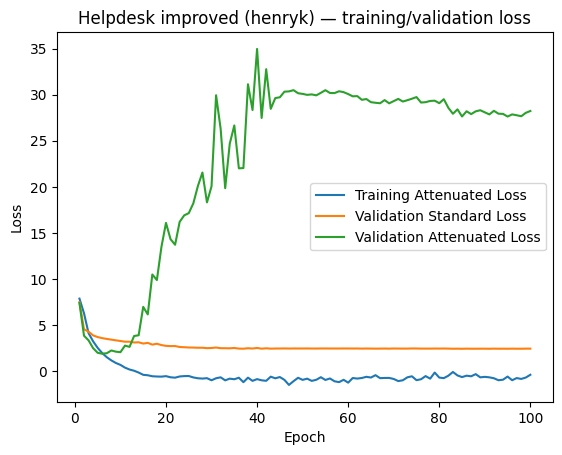

In [10]:
import sys
sys.path.insert(0, '../../../../../../..')  # -> src/
import matplotlib.pyplot as plt

epochs_axis = range(1, num_epochs + 1)
plt.figure()
plt.plot(epochs_axis, train_attenuated_losses, label='Training Attenuated Loss')
plt.plot(epochs_axis, val_losses, label='Validation Standard Loss')
plt.plot(epochs_axis, val_attenuated_losses, label='Validation Attenuated Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Helpdesk improved (henryk) — training/validation loss')
plt.legend()
plt.show()